# 18 — How strong is "lesions fill with vimentin in animals that do well"?

Notebooks 11–16: lesion astrocyte vimentin tends to be higher in milder, never-relapsing and recovering animals. A
strength check (notebook 17 follow-up) found the evidence suggestive but not established: same-day contrasts overlap,
the two clearest contrasts are confounded by run (MILD30 vs SEVERE30) or time (MONOPHASIC d33 vs REMISSION1 d22), and
the association with clinical score is ρ −0.48 in runs 5/6 but −0.07 in runs 1–3. Here, every route to a cleaner
answer:

1. **Within-image pairs** (the cleanest test): for every pair of post-peak animals in the same Xenium image (same
   staining, imaging and run), does the animal with the higher clinical score have less lesion vimentin? Sign test
   over pairs, and per image.
2. **Adjusted per-animal models**: vimentin ~ score + days since the first peak + first-peak height + arm + run;
   leave-one-run-out stability.
3. **Composition**: vimentin within the *same lesion state* (S0, S2, S1/S4), so a shift in lesion state mix cannot
   drive it.
4. **Time**: vimentin vs days since the first peak, within each arm, to separate "resolution takes time" from
   "recovering animals make more".
5. **Beyond RNA**: does lesion vimentin relate to score once RNA astrocyte reactivity is accounted for?
6. **Each arm separately**, and why runs 1–3 differ.

Measure throughout: astrocyte vimentin (cell mean, robust z within image) inside lesion regions (notebook 16) minus
the same animal's astrocytes > 60 µm outside lesions ("within-animal contrast", cancels piece brightness), and the
plain inside value. Post-peak animals: all stages after the first peak.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.spatial import cKDTree
from scipy.stats import binomtest, spearmanr, wilcoxon

from beyondboundaries import plotting

plotting.style()
SRC = "notebooks/18_vimentin_outcome.ipynb"
OUT = ROOT / "results" / "18_vimentin_outcome"
OUT.mkdir(parents=True, exist_ok=True)
COL = plotting.CATEGORICAL
POST = ["PEAK2", "PEAK2_MILD", "PEAK3", "REMISSION1", "REMISSION2", "REMISSION2_LONG", "MONOPHASIC",
        "MILD16", "SEVERE16", "MILD30", "SEVERE30"]

In [2]:
a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
X_genes = ["C3", "Gfap", "Serpina3n", "Cd44", "Osmr", "Timp1", "Socs3", "Serping1",
           "Slc1a3", "Kcnj10", "Slc6a11", "Fgfr3", "Gjb6", "Aldoc", "Aldh1l1"]
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "run_id", "Anno_L1_curated",
             "x_centroid", "y_centroid"]].copy()
obs["stage"] = obs.stage.astype(str)
obs["run"] = obs.run_id.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet")[["lesion_state"]])
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion16" / "regions.parquet"))
ast_idx = obs.index[obs.Anno_L1_curated == "Astrocyte"]
gi = {g: i for i, g in enumerate(a.var_names)}
Xa = a[ast_idx.to_numpy(), [g for g in X_genes if g in gi]].to_memory().X
Xa = Xa.toarray() if hasattr(Xa, "toarray") else np.asarray(Xa)
a.file.close()
ex = pd.DataFrame(Xa, index=ast_idx, columns=[g for g in X_genes if g in gi])
ez = (ex - ex.mean()) / ex.std()
REACT = [g for g in X_genes[:8] if g in ez]
HOMEO = [g for g in X_genes[8:] if g in ez]
obs.loc[ast_idx, "rna_react"] = ez[REACT].mean(1) - ez[HOMEO].mean(1)

fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["section_id", "segmentation_method", "smavim_cell_mean"])
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"]
med = fa.smavim_cell_mean.groupby(fa.section_id).transform("median")
mad = (fa.smavim_cell_mean - med).abs().groupby(fa.section_id).transform("median") * 1.4826
fa["vim_z"] = (fa.smavim_cell_mean - med) / mad
obs = obs.join(fa[["vim_z"]])
other = pd.Series(np.inf, index=obs.index)
for _, g in obs.groupby("sample_id", observed=True):
    xy, pc = g[["x_centroid", "y_centroid"]].to_numpy(), g.meta_sample_id.astype(str).to_numpy()
    for p in np.unique(pc):
        m = pc == p
        if not m.all():
            other[g.index[m]] = cKDTree(xy[~m]).query(xy[m])[0]
obs.loc[other < 20, "vim_z"] = np.nan

clin = pd.read_csv(ROOT / "data" / "clinical" / "animal_course_metrics.csv", index_col=0)
ast = obs[obs.Anno_L1_curated == "Astrocyte"]
inside = ast[ast.reg_dist > 0]
outside = ast[ast.reg_dist < -60]
A = pd.DataFrame({
    "vim_inside": inside.groupby("sample_name", observed=True).vim_z.median(),
    "vim_outside": outside.groupby("sample_name", observed=True).vim_z.median(),
    "n_inside": inside.groupby("sample_name", observed=True).vim_z.count(),
    "rna_react_inside": inside.groupby("sample_name", observed=True).rna_react.median(),
    "lesion_share": obs[obs.lesion_state != "not scored"].groupby("sample_name", observed=True).lesion_state.agg(
        lambda s: s.str.startswith("S").mean()),
})
A["vim_contrast"] = A.vim_inside - A.vim_outside
meta = obs.groupby("sample_name", observed=True).agg(stage=("stage", "first"), arm=("arm", "first"), run=("run", "first"))
A = A.join(meta).join(clin[["score", "day", "first_peak", "first_peak_day", "nadir_after_first", "auc"]])
A["days_since_peak"] = A.day - A.first_peak_day
A = A[A.n_inside >= 30]
P = A[A.stage.isin(POST)].dropna(subset=["vim_contrast", "score"]).copy()
P.to_csv(OUT / "post_peak_animals.csv")
print(len(P), "post-peak animals with ≥ 30 lesion astrocytes |", P.groupby(["arm", "run"]).size().to_dict())

35 post-peak animals with ≥ 30 lesion astrocytes | {('RR', 'run2'): 7, ('RR', 'run3'): 7, ('RR', 'run5'): 3, ('RR', 'run6'): 5, ('chronic', 'run1'): 5, ('chronic', 'run5'): 8}


## 1. Within-image pairs
Every pair of post-peak animals imaged together (same Xenium image, so same staining, imaging and run) with
different clinical scores at sacrifice. Concordant = the animal with the higher score has less lesion vimentin.

In [3]:
img_of = obs[obs.sample_name.isin(P.index)].groupby(["sample_id", "sample_name"], observed=True).size().reset_index()
rows = []
for img, g in img_of.groupby("sample_id", observed=True):
    ans = sorted(set(g.sample_name))
    for x, y in combinations(ans, 2):
        if P.loc[x, "score"] == P.loc[y, "score"]:
            continue
        hi, lo = (x, y) if P.loc[x, "score"] > P.loc[y, "score"] else (y, x)
        for m in ["vim_contrast", "vim_inside"]:
            rows.append(dict(image=img, measure=m, worse=hi, better=lo, worse_stage=P.loc[hi, "stage"],
                             better_stage=P.loc[lo, "stage"], score_diff=P.loc[hi, "score"] - P.loc[lo, "score"],
                             day_diff=P.loc[hi, "day"] - P.loc[lo, "day"],
                             vim_diff=P.loc[hi, m] - P.loc[lo, m]))
pairs = pd.DataFrame(rows).drop_duplicates(["image", "measure", "worse", "better"])
pairs["concordant"] = pairs.vim_diff < 0
pairs.to_csv(OUT / "within_image_pairs.csv", index=False)
summ = []
for m, g in pairs.groupby("measure"):
    # count each animal pair once even if the two animals share several images
    gu = g.groupby(["worse", "better"]).agg(vim_diff=("vim_diff", "mean"), day_diff=("day_diff", "first"),
                                             score_diff=("score_diff", "first")).reset_index()
    k, n = int((gu.vim_diff < 0).sum()), len(gu)
    summ.append(dict(measure=m, animal_pairs=n, concordant=k, share=k / n, sign_test_p=binomtest(k, n, 0.5).pvalue,
                     same_day_pairs=int((gu.day_diff.abs() <= 3).sum()),
                     same_day_concordant=int(((gu.day_diff.abs() <= 3) & (gu.vim_diff < 0)).sum())))
pd.DataFrame(summ).round(3)

,measure,animal_pairs,concordant,share,sign_test_p,same_day_pairs,same_day_concordant
0,vim_contrast,19,12,0.632,0.359,5,4
1,vim_inside,19,12,0.632,0.359,5,4


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/18_vimentin_outcome/within_image_pairs.png')

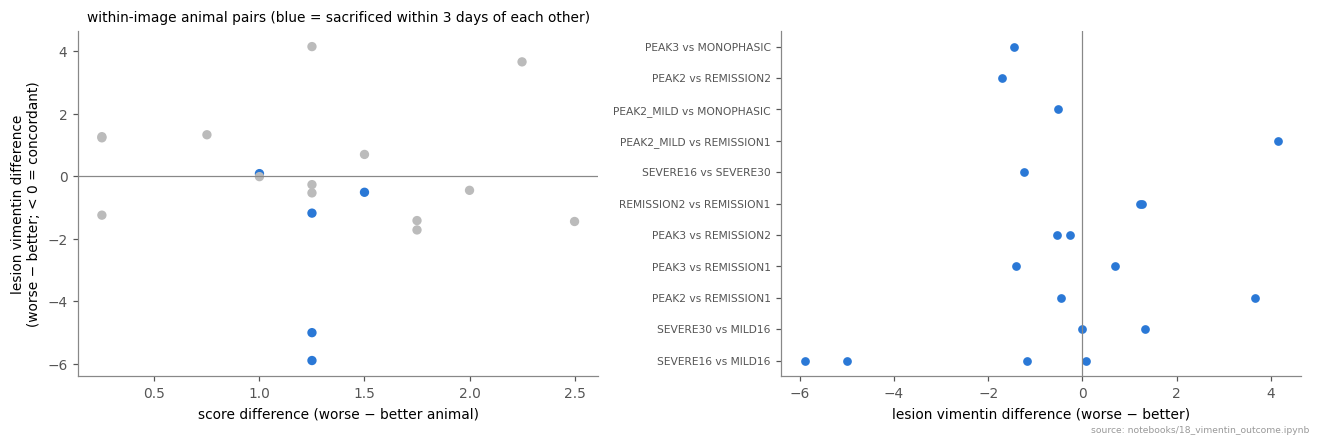

In [4]:
g = pairs[pairs.measure == "vim_contrast"].groupby(["worse", "better"]).agg(
    vim_diff=("vim_diff", "mean"), score_diff=("score_diff", "first"), day_diff=("day_diff", "first"),
    worse_stage=("worse_stage", "first"), better_stage=("better_stage", "first")).reset_index()
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(g.score_diff, g.vim_diff, s=26, c=np.where(g.day_diff.abs() <= 3, COL[0], "#bbbbbb"))
axs[0].axhline(0, color="#888888", lw=0.8)
axs[0].set(xlabel="score difference (worse − better animal)", ylabel="lesion vimentin difference\n(worse − better; < 0 = concordant)")
axs[0].set_title("within-image animal pairs (blue = sacrificed within 3 days of each other)", fontsize=9)
lab = g.worse_stage + " vs " + g.better_stage
order = lab.value_counts().index
for i, l in enumerate(order):
    v = g[lab == l].vim_diff
    axs[1].scatter(v, np.full(len(v), i), s=22, color=COL[0])
axs[1].axvline(0, color="#888888", lw=0.8)
axs[1].set_yticks(range(len(order)), order, fontsize=7)
axs[1].set_xlabel("lesion vimentin difference (worse − better)")
fig.tight_layout()
plotting.save_fig(fig, "within_image_pairs", OUT, SRC)

## 2. Adjusted per-animal models
Rank-based (Spearman on residuals) partial associations between lesion vimentin and score at sacrifice, adding
covariates one at a time; then the full model leaving one run out.

In [5]:
def partial(df, x, y, cov):
    d = df[[x, y] + cov].dropna()
    if cov:
        Z = np.c_[np.ones(len(d)), pd.get_dummies(d[cov], drop_first=True).astype(float).to_numpy()]
        rx = d[x] - Z @ np.linalg.lstsq(Z, d[x].to_numpy(), rcond=None)[0]
        ry = d[y] - Z @ np.linalg.lstsq(Z, d[y].to_numpy(), rcond=None)[0]
    else:
        rx, ry = d[x], d[y]
    r = spearmanr(rx, ry)
    return dict(n=len(d), rho=r.statistic, p=r.pvalue)


rows = []
for x in ["vim_contrast", "vim_inside"]:
    for cov in [[], ["days_since_peak"], ["days_since_peak", "first_peak"], ["days_since_peak", "arm"],
                ["days_since_peak", "run"], ["days_since_peak", "first_peak", "arm"], ["lesion_share"],
                ["days_since_peak", "lesion_share"]]:
        rows.append(dict(vimentin=x, covariates=" + ".join(cov) or "none", **partial(P, x, "score", cov)))
mod = pd.DataFrame(rows)
mod.to_csv(OUT / "adjusted_models.csv", index=False)
mod.round(3)

,vimentin,covariates,n,rho,p
0,vim_contrast,none,35,-0.339,0.046
1,vim_contrast,days_since_peak,35,-0.443,0.008
2,vim_contrast,days_since_peak + first_peak,35,-0.290,0.092
3,vim_contrast,days_since_peak + arm,35,-0.493,0.003
4,vim_contrast,days_since_peak + run,35,-0.352,0.038
5,vim_contrast,days_since_peak + first_peak + arm,35,-0.321,0.060
6,vim_contrast,lesion_share,35,-0.160,0.360
7,vim_contrast,days_since_peak + lesion_share,35,-0.262,0.129
8,vim_inside,none,35,-0.369,0.029
9,vim_inside,days_since_peak,35,-0.490,0.003


In [6]:
loro = []
for run in sorted(P.run.unique()):
    d = P[P.run != run]
    loro.append(dict(left_out=run, **partial(d, "vim_contrast", "score", ["days_since_peak"])))
pd.DataFrame(loro).round(3)

,left_out,n,rho,p
0,run1,30,-0.447,0.013
1,run2,28,-0.545,0.003
2,run3,28,-0.474,0.011
3,run5,24,-0.527,0.008
4,run6,30,-0.415,0.022


## 3. Composition: vimentin within the same lesion state

In [7]:
rows = []
for st in ["S0", "S2", "S1", "S4", "S3"]:
    c = inside[inside.lesion_state.str[:2] == st]
    v = c.groupby("sample_name", observed=True).vim_z.agg(["median", "count"])
    v = v[v["count"] >= 20]["median"]
    d = P.join(v.rename("v"), how="inner")
    for cov in [[], ["days_since_peak"]]:
        rows.append(dict(state=st, covariates=" + ".join(cov) or "none", **partial(d, "v", "score", cov)))
pd.DataFrame(rows).round(3)

,state,covariates,n,rho,p
0,S0,none,35,-0.439,0.008
1,S0,days_since_peak,35,-0.493,0.003
2,S2,none,35,-0.517,0.001
3,S2,days_since_peak,35,-0.560,0.000
4,S1,none,25,-0.507,0.010
5,S1,days_since_peak,25,-0.449,0.024
6,S4,none,27,-0.460,0.016
7,S4,days_since_peak,27,-0.411,0.033
8,S3,none,32,0.032,0.860
9,S3,days_since_peak,32,-0.121,0.511


## 4. Time since the first peak, by arm and outcome

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/18_vimentin_outcome/vimentin_vs_time_by_arm.png')

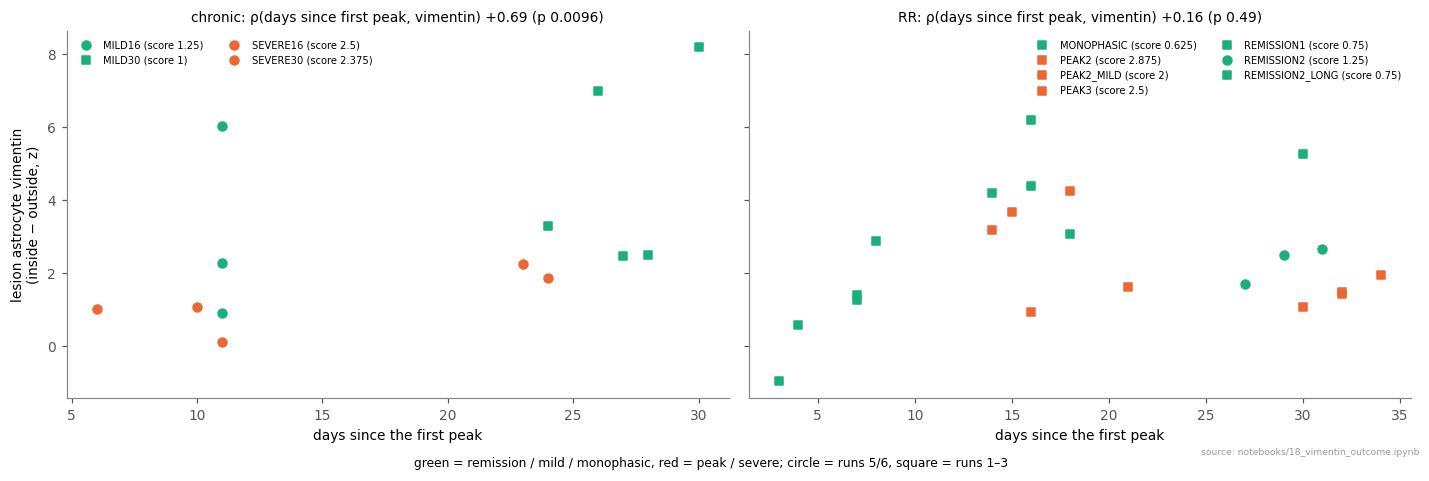

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
GOOD = {"MILD16", "MILD30", "MONOPHASIC", "REMISSION2_LONG", "REMISSION1", "REMISSION2"}
for ax, arm in zip(axs, ["chronic", "RR"]):
    d = P[P.arm == arm]
    for stg, g in d.groupby("stage"):
        ax.scatter(g.days_since_peak, g.vim_contrast, s=34, label=f"{stg} (score {g.score.median():g})",
                   color=COL[2] if stg in GOOD else COL[1], marker="o" if g.run.iloc[0] in ("run5", "run6") else "s")
    r = spearmanr(d.days_since_peak, d.vim_contrast)
    ax.set_title(f"{arm}: ρ(days since first peak, vimentin) {r.statistic:+.2f} (p {r.pvalue:.2g})", fontsize=9)
    ax.set_xlabel("days since the first peak")
    ax.legend(fontsize=6.5, ncol=2)
axs[0].set_ylabel("lesion astrocyte vimentin\n(inside − outside, z)")
fig.text(0.5, -0.02, "green = remission / mild / monophasic, red = peak / severe; circle = runs 5/6, square = runs 1–3",
         ha="center", fontsize=8)
fig.tight_layout()
plotting.save_fig(fig, "vimentin_vs_time_by_arm", OUT, SRC)

In [9]:
rows = []
for arm in ["chronic", "RR"]:
    d = P[P.arm == arm]
    for cov in [[], ["days_since_peak"], ["days_since_peak", "first_peak"]]:
        rows.append(dict(arm=arm, covariates=" + ".join(cov) or "none", **partial(d, "vim_contrast", "score", cov)))
    for rs, runs in [("runs 5/6", ["run5", "run6"]), ("runs 1–3", ["run1", "run2", "run3"])]:
        dd = d[d.run.isin(runs)]
        if len(dd) >= 5:
            rows.append(dict(arm=arm, covariates=f"{rs} only, + days_since_peak",
                             **partial(dd, "vim_contrast", "score", ["days_since_peak"])))
by_arm = pd.DataFrame(rows)
by_arm.round(3)

/tmp/ipykernel_2574/1735831127.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = spearmanr(rx, ry)


,arm,covariates,n,rho,p
0,chronic,none,13,-0.830,0.000
1,chronic,days_since_peak,13,-0.558,0.047
2,chronic,days_since_peak + first_peak,13,-0.308,0.306
3,chronic,"runs 5/6 only, + days_since_peak",8,-0.611,0.108
4,chronic,"runs 1–3 only, + days_since_peak",5,NaN,NaN
5,RR,none,22,-0.183,0.414
6,RR,days_since_peak,22,-0.386,0.076
7,RR,days_since_peak + first_peak,22,-0.517,0.014
8,RR,"runs 5/6 only, + days_since_peak",8,-0.833,0.010
9,RR,"runs 1–3 only, + days_since_peak",14,-0.459,0.098


In [10]:
print("score range by arm × run set (post-peak):")
P.assign(runset=np.where(P.run.isin(["run5", "run6"]), "runs 5/6", "runs 1–3")).groupby(["arm", "runset"]).agg(
    n=("score", "size"), score_min=("score", "min"), score_max=("score", "max"), stages=("stage", lambda s: sorted(set(s))))

score range by arm × run set (post-peak):


n  score_min  score_max  \
arm     runset                               
RR      runs 1–3  14       0.50        3.0   
        runs 5/6   8       0.75        3.0   
chronic runs 1–3   5       1.00        1.0   
        runs 5/6   8       1.25        2.5   

                                                             stages  
arm     runset                                                       
RR      runs 1–3  [MONOPHASIC, PEAK2, PEAK2_MILD, PEAK3, REMISSI...  
        runs 5/6             [PEAK2, PEAK3, REMISSION1, REMISSION2]  
chronic runs 1–3                                           [MILD30]  
        runs 5/6                       [MILD16, SEVERE16, SEVERE30]

## 5. Beyond RNA astrocyte reactivity
RNA reactivity of lesion astrocytes (reactive − homeostatic genes, notebook 06) per animal. Does vimentin protein
relate to score beyond it?

In [11]:
rows = [dict(model="RNA reactivity vs score", **partial(P, "rna_react_inside", "score", ["days_since_peak"])),
        dict(model="vimentin vs score | RNA reactivity", **partial(P, "vim_contrast", "score", ["days_since_peak", "rna_react_inside"])),
        dict(model="vimentin vs RNA reactivity", **partial(P, "vim_contrast", "rna_react_inside", []))]
pd.DataFrame(rows).round(3)

,model,n,rho,p
0,RNA reactivity vs score,35,0.288,0.093
1,vimentin vs score | RNA reactivity,35,-0.633,0.000
2,vimentin vs RNA reactivity,35,0.178,0.307


## Findings

> **Finding — a moderate, robust association that can't be separated from disease burden.** Across 35 post-peak
> animals, lesion astrocyte vimentin (inside − outside) goes with a lower clinical score: ρ −0.34 (p = 0.046), −0.44
> adjusted for days since the first peak (p = 0.008). It holds when each run is left out in turn (ρ −0.42 to −0.55,
> all p < 0.03), within the same lesion state (S0 −0.49, S2 −0.56, S1 −0.45, S4 −0.41 with time adjustment, all
> p < 0.04), and in both arms once time and first-attack height are accounted for (RR ρ −0.52, p = 0.01).
> Adjusting for lesion share (ρ −0.26, n.s.) or first-attack height (−0.29, p = 0.09) weakens it: animals with bigger
> attacks have more lesion and less vimentin, and 35 animals can't separate the two.
>
> **Finding — the strict same-image test is weak.** Of 19 animal pairs imaged together with different scores, the
> worse animal has less lesion vimentin in 12 (63 %, sign test p = 0.36); same-day pairs 4 of 5.
>
> **Finding — runs 1–3 did not fail to replicate; they had no score variance.** The only chronic post-peak animals in
> runs 1–3 are MILD30, all with score 1.0. Within the RR arm, runs 1–3 show the same direction (ρ −0.46, p = 0.10).
>
> **Finding — vimentin protein carries information the RNA doesn't.** Astrocyte RNA reactivity in lesions rises
> slightly with worse scores (ρ +0.29), vimentin protein falls; vimentin and RNA reactivity are only weakly related
> (ρ 0.18), and vimentin vs score adjusted for RNA reactivity is ρ −0.63 (p < 0.001). Worse animals have reactive
> transcription without the vimentin protein, consistent with RNA preceding protein (notebooks 06, 13).
>
> **Overall strength: moderate.** Direction consistent across every contrast and robust to run, time, lesion state and
> RNA reactivity (ρ ≈ −0.45), but entangled with overall disease burden and only weakly supported by within-image
> pairs. A hypothesis with decent support, not an established result; separate vimentin/GFAP antibodies on more
> animals at matched days would settle it.